# 03A - Baseline CNN with Augmentation Only

This experiment keeps the same custom CNN as the plain baseline, but adds on-the-fly image augmentation during training only.

No class weights are used in this run. The purpose is to isolate whether augmentation itself improves generalisation before trying any imbalance-specific weighting strategy.

Compare against `02_baseline_cnn.ipynb`:

- plain baseline test accuracy: about 0.7555
- plain baseline macro F1: about 0.7008


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system


## 2. Imports and configuration


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    SPLITS_DIR,
)
from src.data.augmentations import build_training_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.models.baseline_cnn import build_baseline_cnn
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "baseline_cnn_aug_only"
EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)


TensorFlow: 2.21.0
GPUs: []
Experiment: baseline_cnn_aug_only


## 3. Load split files and class names


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Train/val/test: 20493 4392 4392
Classes: 28


## 4. Build TensorFlow datasets

Augmentation is part of the model graph, not the dataset pipeline. Keras random augmentation layers run during training and stay inactive during validation/test inference.


In [4]:
train_ds = make_dataset_from_dataframe(train_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 5. Build and train augmentation-only baseline


In [5]:
EPOCHS = 12
LEARNING_RATE = 1e-3

checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_best.keras"

augmentation = build_training_augmentation()
model = build_baseline_cnn(num_classes=NUM_CLASSES, augmentation=augmentation)
model = compile_model(model, learning_rate=LEARNING_RATE)
model.summary()

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    checkpoint_path=checkpoint_path,
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,860 (378.36 KB)

 Trainable params: 96,860 (378.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 242s 375ms/step - accuracy: 0.2415 - loss: 2.5352 - val_accuracy: 0.3736 - val_loss: 2.0513 - learning_rate: 0.0010
Epoch 2/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 222s 345ms/step - accuracy: 0.4042 - loss: 1.9390 - val_accuracy: 0.4738 - val_loss: 1.7361 - learning_rate: 0.0010
Epoch 3/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 225s 349ms/step - accuracy: 0.4834 - loss: 1.7045 - val_accuracy: 0.5640 - val_loss: 1.4866 - learning_rate: 0.0010
Epoch 4/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 222s 346ms/step - accuracy: 0.5422 - loss: 1.5273 - val_accuracy: 0.6148 - val_loss: 1.3449 - learning_rate: 0.0010
Epoch 5/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 218s 339ms/step - accuracy: 0.5899 - loss: 1.3821 - val_accuracy: 0.6075 - val_loss: 1.2743 - learning_rate: 0.0010
Epoch 6/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 221s 344ms/step - accuracy: 0.6163 - loss: 1.3015 - val_accuracy: 0.6721 - val_loss: 1.1577 - learning_rate: 0.0010
Epoch 7/12
641/641 ━━━━━━━━━━━━━━━━━━━━ 221s 344ms/step - accura

## 6. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate
7,0.653784,1.165763,0.682605,1.048240,0.0010
8,0.672425,1.116215,0.731785,0.944778,0.0010
9,0.682184,1.069672,0.695811,0.986152,0.0010
10,0.704241,1.005832,0.703097,0.995534,0.0010
11,0.729176,0.914923,0.739299,0.887291,0.0002


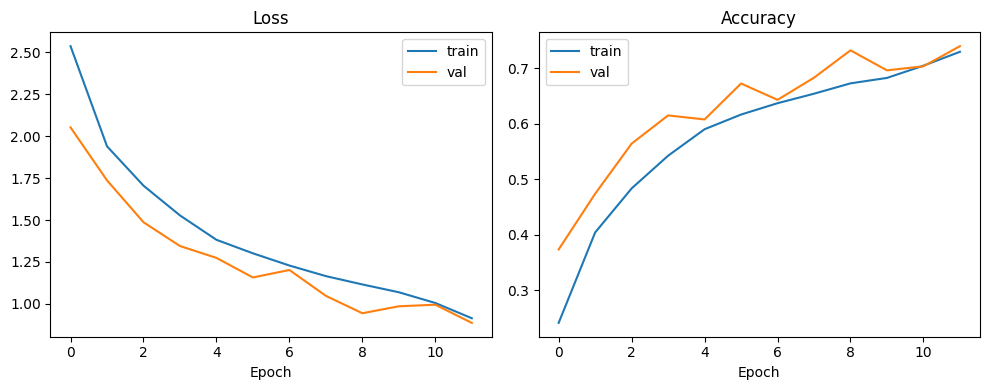

In [6]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train")
plt.plot(history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train")
plt.plot(history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 7. Evaluate on test set


In [7]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


,precision,recall,f1-score,support
Apple__Healthy,0.832861,0.805479,0.818942,365.000000
Apple__Rotten,0.737991,0.769932,0.753623,439.000000
Banana__Healthy,0.833910,0.803333,0.818336,300.000000
Banana__Rotten,0.795082,0.926014,0.855568,419.000000
Bellpepper__Healthy,0.839080,0.793478,0.815642,92.000000
Bellpepper__Rotten,0.462963,0.280899,0.349650,89.000000
Carrot__Healthy,0.756098,0.666667,0.708571,93.000000
Carrot__Rotten,0.543478,0.574713,0.558659,87.000000
Cucumber__Healthy,0.647541,0.868132,0.741784,91.000000
Cucumber__Rotten,0.775281,0.775281,0.775281,89.000000


Test accuracy: 0.7502
Macro F1: 0.6984
Weighted F1: 0.7447


## 8. Focus on weak classes from the plain baseline


In [8]:
weak_classes_from_plain_baseline = [
    "Tomato__Rotten",
    "Bellpepper__Rotten",
    "Potato__Rotten",
    "Pomegranate__Rotten",
    "Carrot__Rotten",
]

available_weak_classes = [name for name in weak_classes_from_plain_baseline if name in report_df.index]
display(report_df.loc[available_weak_classes, ["precision", "recall", "f1-score", "support"]])


,precision,recall,f1-score,support
Tomato__Rotten,0.608696,0.311111,0.411765,90.0
Bellpepper__Rotten,0.462963,0.280899,0.349650,89.0
Potato__Rotten,0.471264,0.471264,0.471264,87.0
Pomegranate__Rotten,0.538462,0.233333,0.325581,30.0
Carrot__Rotten,0.543478,0.574713,0.558659,87.0


## 9. Confusion matrix


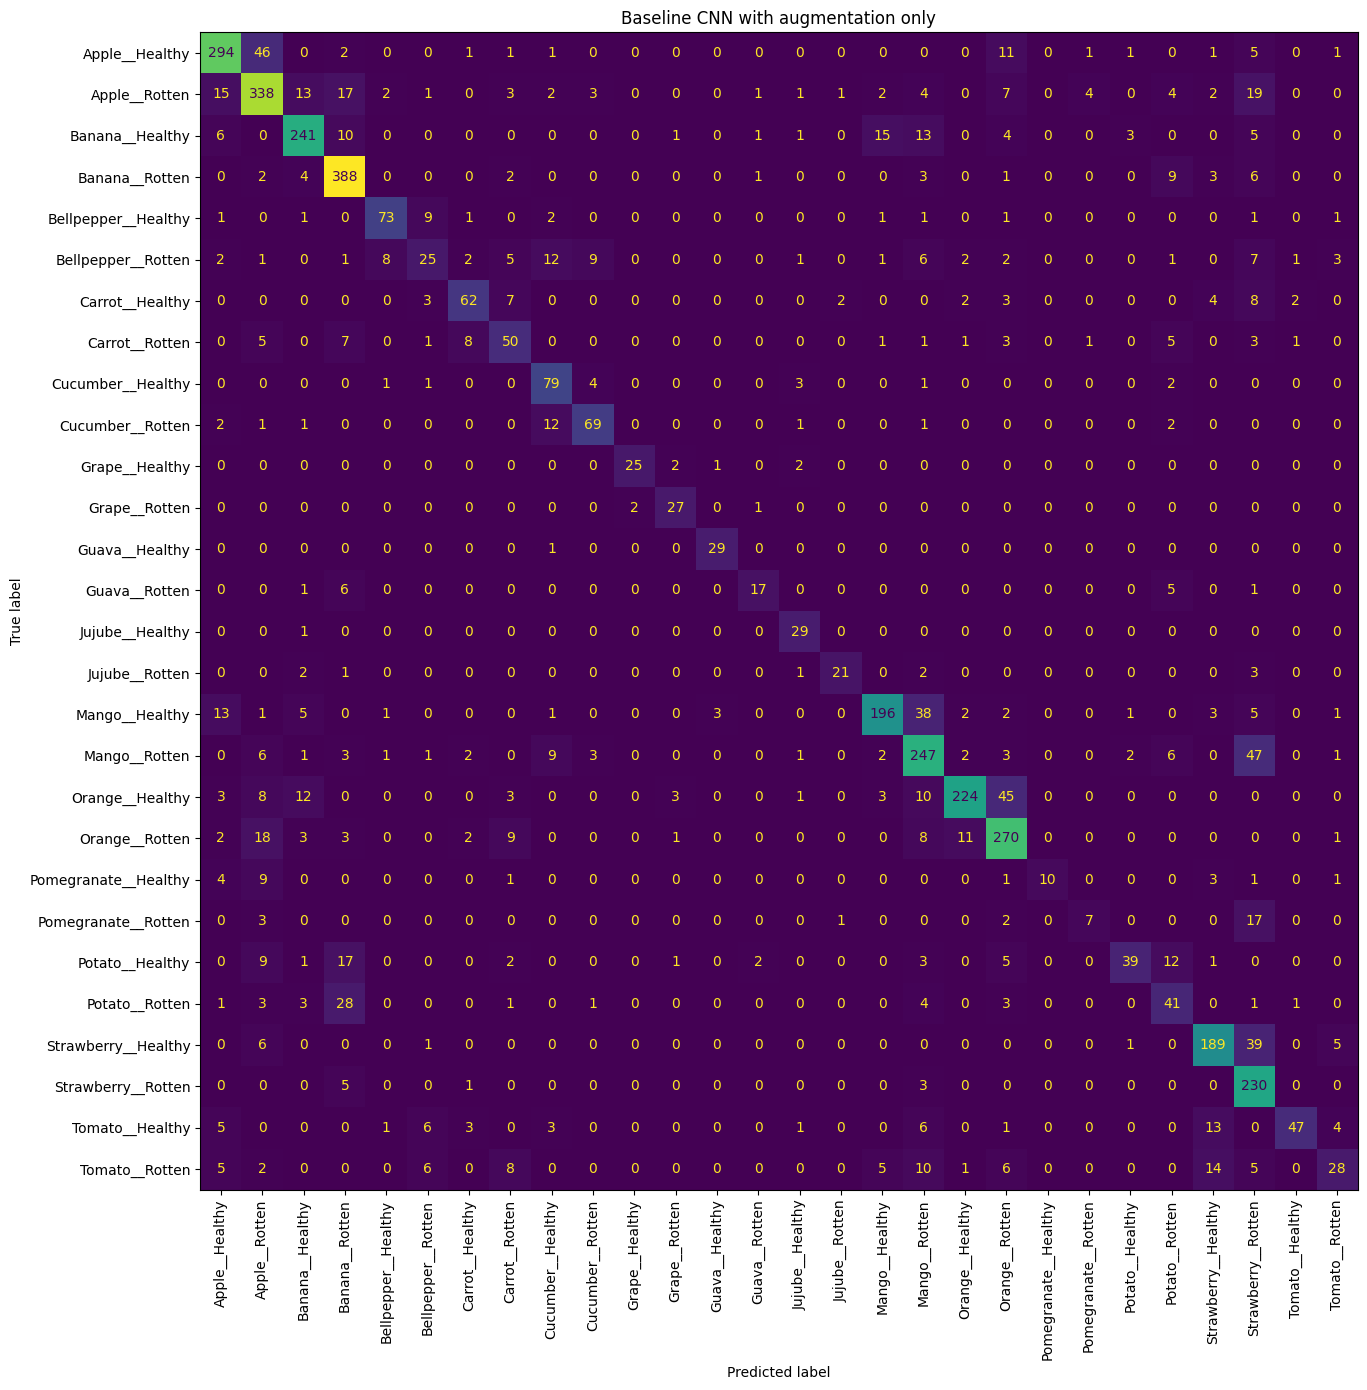

In [9]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Baseline CNN with augmentation only")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 10. Save experiment artifacts

This notebook does not overwrite `models/best_model.keras`. That file should only be updated after comparing all candidate models.


In [10]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"

model.save(model_path)
report_df.to_csv(report_path)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "custom_baseline_cnn",
    "dataset": "muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten",
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "epochs_requested": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "augmentation": True,
    "class_weighting": None,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
    "artifacts": {
        "model": str(model_path),
        "checkpoint": str(checkpoint_path),
        "metadata": str(metadata_path),
        "classification_report": str(report_path),
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved experiment model:", model_path)
print("Saved checkpoint:", checkpoint_path)
print("Saved metadata:", metadata_path)
print("Did not overwrite models/best_model.keras")


Saved experiment model: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_only.keras
Saved checkpoint: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_only_best.keras
Saved metadata: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\experiments\baseline_cnn_aug_only_metadata.json
Did not overwrite models/best_model.keras


## 11. Decision rule

Compare this experiment against:

- plain baseline: accuracy about 0.7555, macro F1 about 0.7008
- previous aug + full class weights: accuracy about 0.6776, macro F1 about 0.6347

If augmentation-only performs close to or better than the plain baseline, augmentation is useful and full class weights were the main problem. If augmentation-only also drops strongly, the augmentation policy is too strong for this small baseline CNN and should be softened before trying `03B`.
